In [1]:
import albumentations as A
import torch
from albumentations.pytorch import ToTensorV2
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.patches as patches
from torchvision import  datasets, transforms
import torch.nn.functional as F

In [2]:
A.__version__

'2.0.8'

In [3]:
image = np.random.randint(100, 160, (480, 640, 3), dtype=np.uint8)
image[300:480, :]        = [80,  80,  80]   # асфальт
image[100:320, 80:440]   = [50, 120, 200]   # кузов автомобиля
image[110:220, 140:290]  = [180, 220, 255]  # лобовое стекло
image[280:330, 60:150]   = [20,  20,  20]   # переднее колесо
image[280:330, 330:420]  = [20,  20,  20]   # заднее колесо

In [4]:
bbox = [[ 80, 100, 440, 340]] # x1, y1, x2, y2

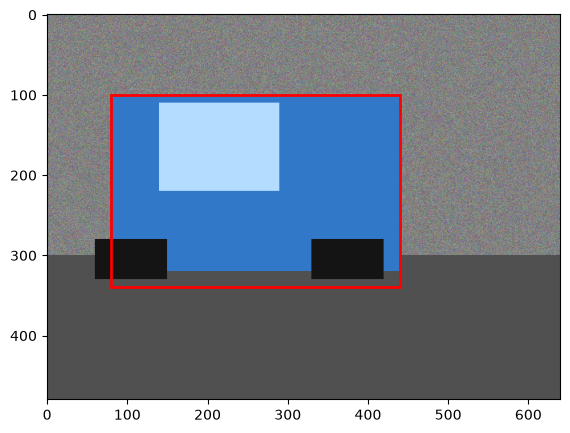

In [5]:
fig, axes = plt.subplots(1,1, figsize=(14,5))

axes.imshow(image)

rect = patches.Rectangle(
    (bbox[0][0], bbox[0][1]),
    bbox[0][2] - bbox[0][0],
    bbox[0][3] - bbox[0][1],
    linewidth=2, edgecolor='red', facecolor='none'
)

axes.add_patch(rect)

In [6]:
transfrom = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.4),
        A.GaussNoise(std_range=(2.23/255.0, 5.47/255.0), p=0.5),
        A.MotionBlur(blur_limit=3, p=0.5),
        A.RandomShadow(p=0.5),
        ToTensorV2()
    ]
)

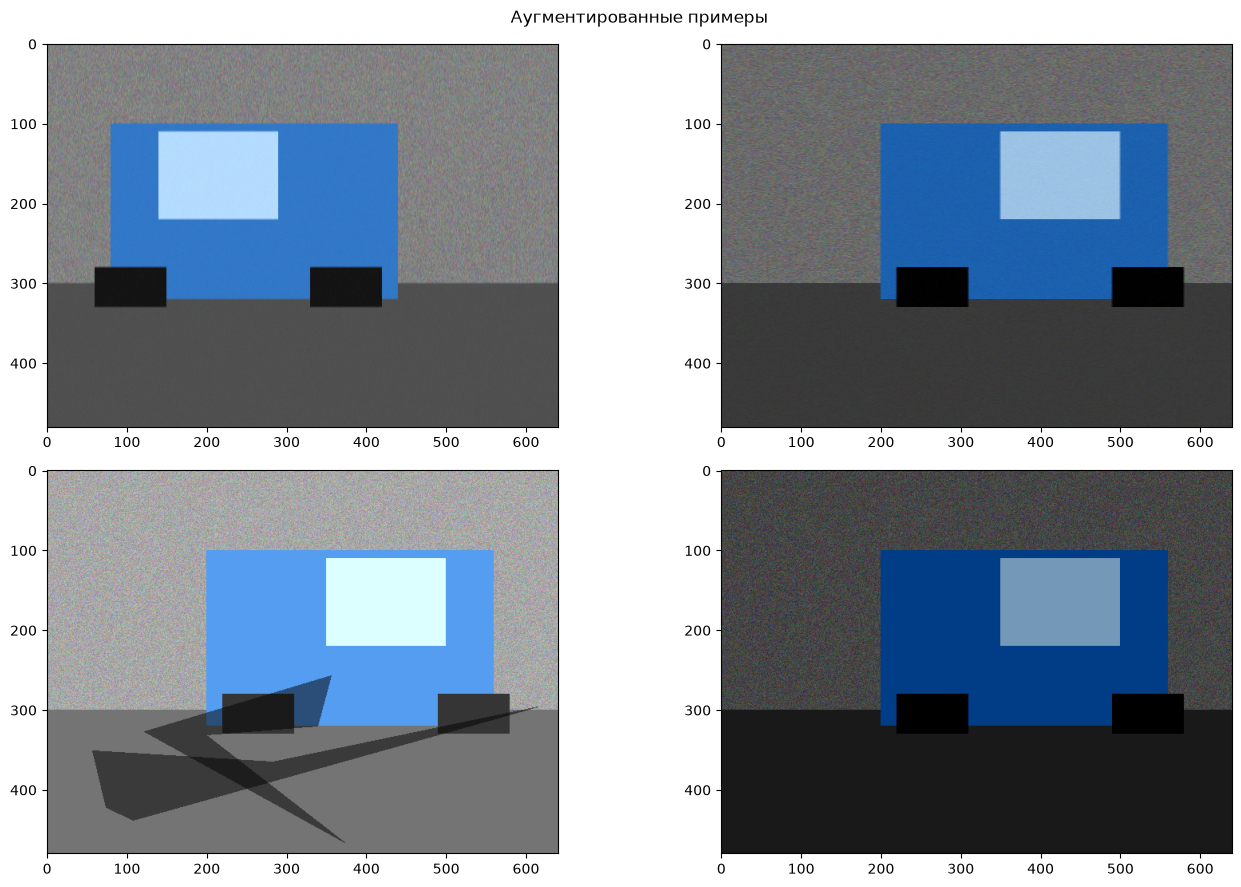

In [7]:
fig, axes = plt.subplots(2,2, figsize=(14,9))

for ax in axes.ravel():
    aug = transfrom(image=image, bbox=bbox)
    ax.imshow(aug['image'].permute(1,2,0).cpu().numpy())

plt.suptitle('Аугментированные примеры')
plt.tight_layout()

## MixUp

In [8]:
to_tensor = transforms.ToTensor()

full_trainset = datasets.CIFAR10(root='input_data', train=True, download=True)#, transform=transform)
targets_all = np.array(full_trainset.classes)

In [9]:
def mixup(img1, label1, img2, label2, alpha=0.4, num_classes=10):

    lam = float(np.random.beta(alpha, alpha))

    mixed_img = lam * img1 + (1 - lam) * img2
    y1 = F.one_hot(torch.tensor(label1), num_classes).float()
    y2 = F.one_hot(torch.tensor(label2), num_classes).float()

    mixed_label = lam * y1 + (1 - lam) * y2

    return mixed_img, mixed_label, lam

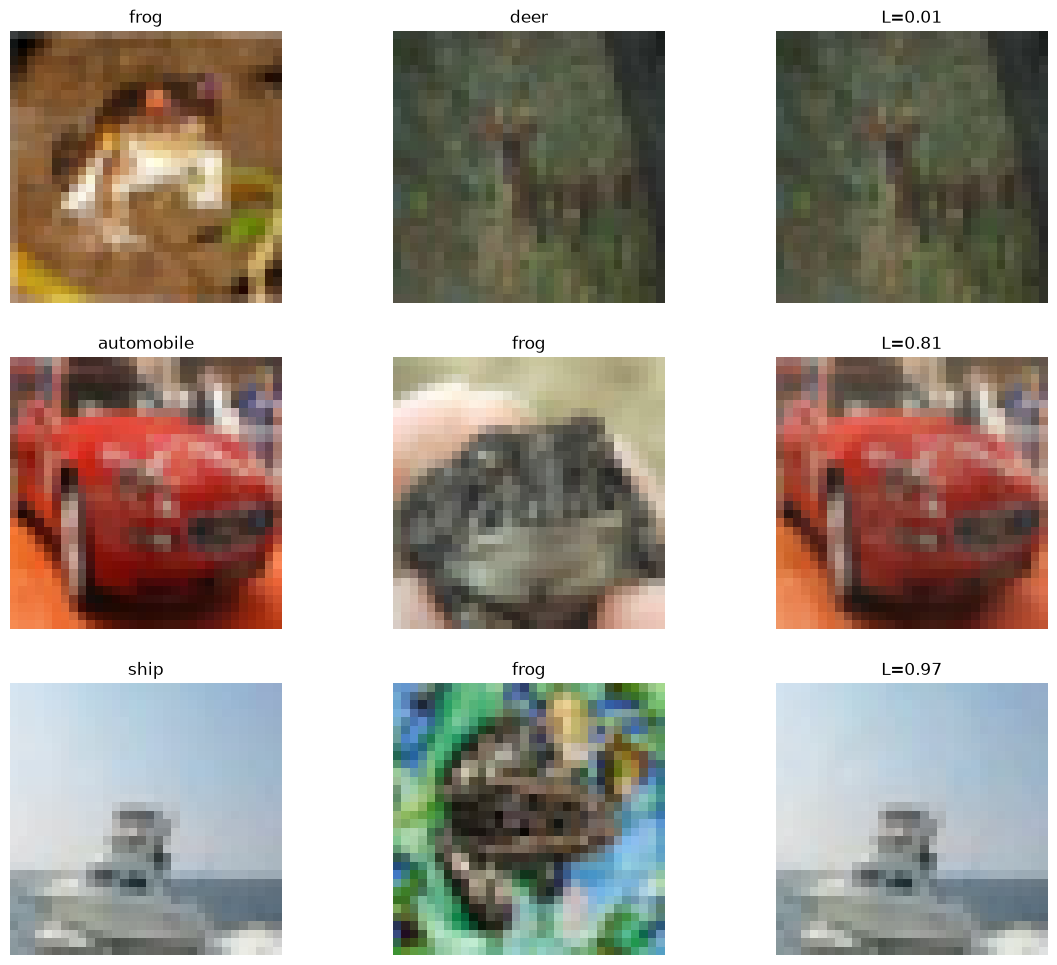

In [10]:
pairs = [(0,10), (5,25), (100,200)]

np.random.seed(19)

fig, axes = plt.subplots(len(pairs), 3, figsize=(14,12))

for row, (i, j) in enumerate(pairs):

    img1_pil, label1 = full_trainset[i]
    img2_pil, label2 = full_trainset[j]

    img1 = to_tensor(img1_pil)
    img2 = to_tensor(img2_pil)

    mixed, soft_label, lam = mixup(img1, label1, img2, label2)

    for col, (tensor, title) in enumerate(
        [
            (img1, targets_all[label1]),
            (img2, targets_all[label2]),
            (mixed, f'L={lam:.2f}'),
        ]
    ):

        ax = axes[row, col]
        ax.imshow(tensor.permute(1,2,0).cpu().numpy())
        ax.set_title(title)
        ax.axis('off')

